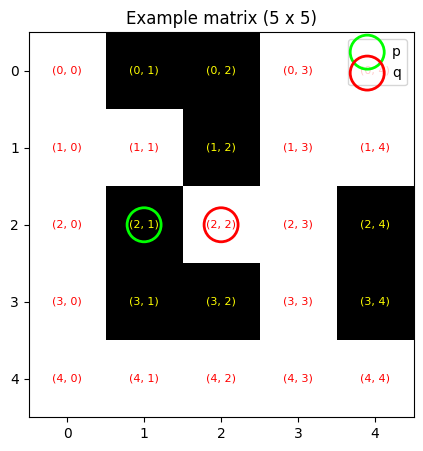

-----Neighbor for p = (2, 1)
Neighbors N4:  [(1, 1), (3, 1), (2, 0), (2, 2)]
Neighbors N0:  [(1, 0), (3, 2), (3, 0), (1, 2)]
Neighbors N8:  [(1, 1), (3, 1), (2, 0), (2, 2), (1, 0), (3, 2), (3, 0), (1, 2)]

 Addjacency between p = (2, 1) and q = (2, 2)
4-adjacency:  False
8-adjacency:  False
m-adjacency:  False

 Distance between p = (2, 1) and q = (2, 2)
Euclidean distance:  1.0
4-distance:  1
8-distance:  1


In [12]:
import numpy as np
import matplotlib.pyplot as plt


matrix = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1],
    [0, 1, 1, 0, 1],
    [0, 0, 0, 0, 0],
])

p = (2,1)
q = (2,2)
v = {1}

fig, axis = plt.subplots(figsize=(5,5))
axis.imshow(matrix, cmap='gray_r')

for row in range(matrix.shape[0]):
  for col in range(matrix.shape[1]):
    axis.text(col, row, f'({row}, {col})', ha='center', va='center',
              color='red' if matrix[row, col] == 0 else 'yellow', fontsize=8)

axis.scatter([p[1]], [p[0]], s=600, facecolors = 'none', edgecolors='lime', linewidths=2, label='p')
axis.scatter([q[1]], [q[0]], s=600, facecolors = 'none', edgecolors='red', linewidths=2, label='q')
axis.legend(loc='upper right')

axis.set_title('Example matrix (5 x 5)')
plt.show()


def n_4(p, f):
  row, col = p
  candidates = [(row-1, col), (row+1, col),(row, col-1), (row, col+1)]
  return [c for c in candidates if 0 <= c[0] < f[0] and 0 <= c[1] < f[1]]

def n_0(p, f):
  row, col = p
  candidates = [(row-1, col-1), (row+1, col+1),(row+1, col-1), (row-1, col+1)]
  return [c for c in candidates if 0 <= c[0] < f[0] and 0 <= c[1] < f[1]]

def n_8(p, f):
  return n_4(p, f)+n_0(p, f)

print(f'-----Neighbor for p = {p}')
print('Neighbors N4: ', n_4(p, matrix.shape))
print('Neighbors N0: ', n_0(p, matrix.shape))
print('Neighbors N8: ', n_8(p, matrix.shape))

def adjacency_4(p, q, matrix, v):
  value_p = matrix[p]
  value_q = matrix[q]
  return (value_p in v) and (value_q in v) and (q in n_4(p, matrix.shape))

def adjacency_8(p, q, matrix, v):
  value_p = matrix[p]
  value_q = matrix[q]
  return (value_p in v) and (value_q in v) and (q in n_8(p, matrix.shape))

def adjacency_m(p, q, matrix, v):
  if not (matrix[p] in v and matrix[q] in v):
    return False
  if q in n_4(p, matrix.shape):
    return True
  if q in n_0(p, matrix.shape):
    commons = set(n_4(p, matrix.shape)) & set(n_4(q, matrix.shape))
    commons_v = [c for c in commons if matrix[c] in v]
    return len(commons_v)==0
  return False

print(f'\n Addjacency between p = {p} and q = {q}')
print('4-adjacency: ', adjacency_4(p, q, matrix, v ))
print('8-adjacency: ', adjacency_8(p, q, matrix, v ))
print('m-adjacency: ', adjacency_m(p, q, matrix, v ))

def euclidean_d(p, q):
  return np.sqrt((p[0] - q[0])**2 + (p[1] - q[1])**2)

def distance_4(p, q):# city-block
  return abs(p[0]-q[0])+abs(p[1]-q[1])

def distance_8(p, q):# chessboard
  return max(abs(p[0] - q[0]), abs(p[1] - q[1]))

print(f'\n Distance between p = {p} and q = {q}')
print('Euclidean distance: ', euclidean_d(p, q))
print('4-distance: ', distance_4(p, q))
print('8-distance: ', distance_8(p, q))
